# Group 51 — Model Comparison: v1 vs v2

Compares `primary_best.pth` from `models/` (v1) against `models_v2/` (v2) on the same test set.

**What you get:**
- Overall accuracy for both models
- Per-class precision / recall / F1
- Side-by-side confusion matrices
- Per-class F1 bar chart
- Δ accuracy summary

### Before running:
1. Make sure `waste_env` is active and the kernel is set to **Python (waste_env)**
2. Train v2 first so `models_v2/primary_best.pth` exists
3. Update paths in **Cell 2** if needed

## Cell 1 — Check environment

In [12]:
import sys, os, platform
import torch
import torchvision

print(f'Python       : {sys.version}')
print(f'Platform     : {platform.platform()}')
print(f'PyTorch      : {torch.__version__}')
print(f'Torchvision  : {torchvision.__version__}')
print()

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Device: CUDA — {torch.cuda.get_device_name(0)}')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')

Python       : 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
Platform     : macOS-26.5.1-arm64-arm-64bit
PyTorch      : 2.11.0
Torchvision  : 0.26.0

Device: MPS (Apple Silicon GPU)


## Cell 2 — Config (edit paths here)

In [13]:
import os
from pathlib import Path

# ── PATHS — update if your layout is different ─────────────────────────────
BASE         = Path(os.path.expanduser('~/Downloads/Capstone_project/model_and_data_pipeline'))

V1_MODEL     = BASE / 'models'    / 'primary_best.pth'
V2_MODEL     = BASE / 'models_v2' / 'primary_best.pth'

V1_JSON      = BASE / 'models'    / 'class_indices.json'
V2_JSON      = BASE / 'models_v2' / 'class_indices.json'

V1_TEST_DIR  = BASE / 'dataset'   / 'test'
V2_TEST_DIR  = BASE / 'dataset_v2' / 'test'

OUTPUT_DIR   = BASE / 'comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── SETTINGS ───────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXT     = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('Paths configured.')
print(f'  v1 model : {V1_MODEL}  — exists: {V1_MODEL.exists()}')
print(f'  v2 model : {V2_MODEL}  — exists: {V2_MODEL.exists()}')
print(f'  v1 test  : {V1_TEST_DIR} — exists: {V1_TEST_DIR.exists()}')
print(f'  v2 test  : {V2_TEST_DIR} — exists: {V2_TEST_DIR.exists()}')

Paths configured.
  v1 model : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models/primary_best.pth  — exists: True
  v2 model : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/primary_best.pth  — exists: True
  v1 test  : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset/test — exists: True
  v2 test  : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2/test — exists: True


## Cell 3 — Load class indices & resolve test set

In [14]:
import json

# Use v2 class indices if available (it has all classes), else fall back to v1
json_path = V2_JSON if V2_JSON.exists() else V1_JSON
test_dir  = V2_TEST_DIR if V2_TEST_DIR.exists() else V1_TEST_DIR

print(f'Using class indices : {json_path}')
print(f'Using test dir      : {test_dir}')

with open(json_path) as f:
    CLASS_TO_IDX = json.load(f)

IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
CLASS_NAMES  = [IDX_TO_CLASS[i] for i in range(len(IDX_TO_CLASS))]
NUM_CLASSES  = len(CLASS_NAMES)

print(f'\nClasses ({NUM_CLASSES}): {CLASS_NAMES}')

Using class indices : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/class_indices.json
Using test dir      : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2/test

Classes (8): ['e-waste', 'general_trash', 'glass', 'hazardous', 'metal', 'organic', 'paper', 'plastic']


## Cell 4 — Build test dataset & dataloader

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class WasteTestDataset(Dataset):
    def __init__(self, test_dir, class_to_idx, transform):
        self.samples = []
        self.transform = transform
        for cls, idx in class_to_idx.items():
            cls_dir = Path(test_dir) / cls
            if not cls_dir.exists():
                continue
            for f in cls_dir.iterdir():
                if f.suffix.lower() in VALID_EXT:
                    self.samples.append((str(f), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

test_dataset = WasteTestDataset(test_dir, CLASS_TO_IDX, test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Test images loaded: {len(test_dataset)}')

Test images loaded: 9982


## Cell 5 — Build model (EfficientNetB0, same head as training)

In [16]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_primary_model(num_classes, dropout_rate=0.4):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return model

print('Model builder ready.')

Model builder ready.


## Cell 6 — Evaluate both models

In [17]:
import numpy as np
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluate_model(model_path, label):
    if not Path(model_path).exists():
        print(f'⚠  {label} not found at {model_path} — skipping.')
        return None

    print(f'Loading {label} …')
    model = build_primary_model(NUM_CLASSES).to(DEVICE)

    state = torch.load(model_path, map_location=DEVICE)
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    model.load_state_dict(state)
    model.eval()

    all_preds, all_labels = [], []
    for images, labels in tqdm(test_loader, desc=f'  {label}'):
        images = images.to(DEVICE)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    labels_arr = np.array(all_labels)
    preds_arr  = np.array(all_preds)
    acc = accuracy_score(labels_arr, preds_arr)
    print(f'  ✓ {label} accuracy: {acc*100:.2f}%\n')
    return {'labels': labels_arr, 'preds': preds_arr, 'acc': acc}

results = {}
r1 = evaluate_model(V1_MODEL, 'v1 (original)')
r2 = evaluate_model(V2_MODEL, 'v2 (new data)')

if r1: results['v1 (original)'] = r1
if r2: results['v2 (new data)'] = r2

Loading v1 (original) …


  v1 (original):   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ v1 (original) accuracy: 65.82%

Loading v2 (new data) …


  v2 (new data):   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ v2 (new data) accuracy: 79.89%



## Cell 7 — Classification report

In [18]:
from sklearn.metrics import classification_report

report_text = 'GROUP 51 — MODEL COMPARISON REPORT\n' + '='*60 + '\n\n'

for name, r in results.items():
    rep = classification_report(r['labels'], r['preds'], target_names=CLASS_NAMES, digits=3)
    header = f'── {name}  (overall acc: {r["acc"]*100:.2f}%) ──'
    print(header)
    print(rep)
    report_text += header + '\n' + rep + '\n'

report_path = OUTPUT_DIR / 'comparison_report.txt'
with open(report_path, 'w') as f:
    f.write(report_text)
print(f'Report saved → {report_path}')

── v1 (original)  (overall acc: 65.82%) ──
               precision    recall  f1-score   support

      e-waste      0.678     0.515     0.585       474
general_trash      0.794     0.857     0.824      1354
        glass      0.501     0.935     0.653       619
    hazardous      0.327     0.993     0.492       146
        metal      0.397     0.926     0.556       392
      organic      0.881     0.628     0.733      3490
        paper      0.520     0.816     0.635      1133
      plastic      0.698     0.406     0.513      2374

     accuracy                          0.658      9982
    macro avg      0.599     0.759     0.624      9982
 weighted avg      0.724     0.658     0.659      9982

── v2 (new data)  (overall acc: 79.89%) ──
               precision    recall  f1-score   support

      e-waste      0.782     0.947     0.857       474
general_trash      0.875     0.897     0.885      1354
        glass      0.639     0.906     0.749       619
    hazardous      0.524     0

## Cell 8 — Confusion matrices

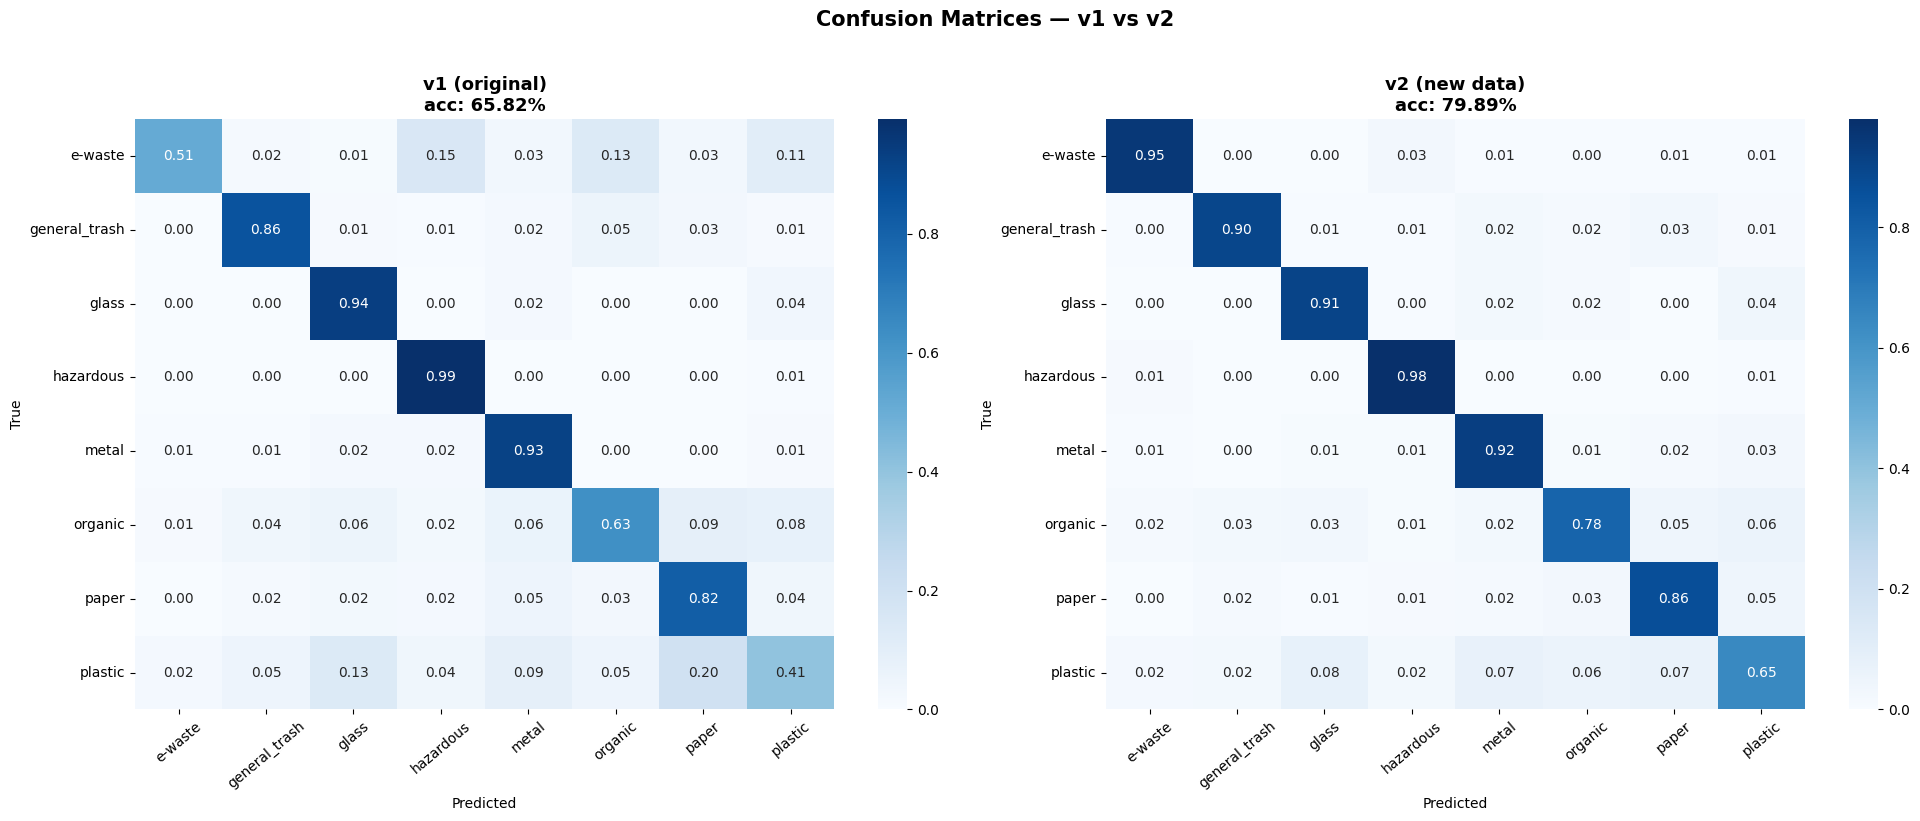

Saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison/confusion_matrices.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(results), figsize=(10 * len(results), 8))
if len(results) == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    cm      = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name}\nacc: {r["acc"]*100:.2f}%', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=40)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrices — v1 vs v2', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
cm_path = OUTPUT_DIR / 'confusion_matrices.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {cm_path}')

## Cell 9 — Per-class F1 comparison

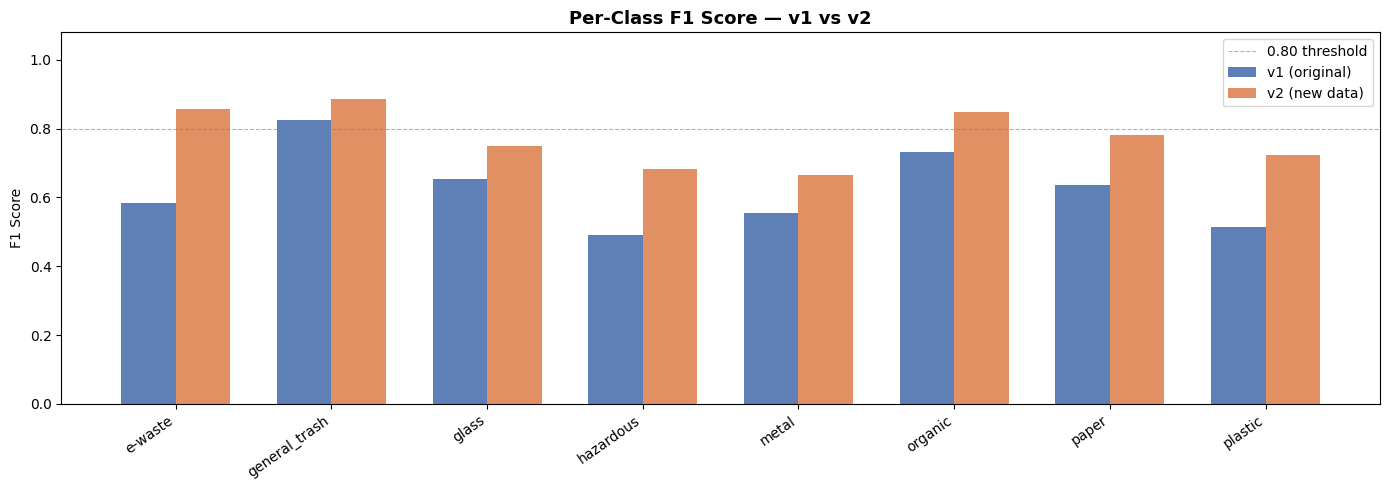

Saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison/f1_comparison.png


In [20]:
from sklearn.metrics import f1_score

names = list(results.keys())
f1s   = [
    f1_score(results[n]['labels'], results[n]['preds'],
             average=None, labels=list(range(NUM_CLASSES)))
    for n in names
]

x   = np.arange(NUM_CLASSES)
w   = 0.35
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, f1, color) in enumerate(zip(names, f1s, colors)):
    offset = (i - 0.5) * w
    bars = ax.bar(x + offset, f1, w, label=name, color=color, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — v1 vs v2', fontsize=13, fontweight='bold')
ax.axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='0.80 threshold')
ax.legend()
plt.tight_layout()
f1_path = OUTPUT_DIR / 'f1_comparison.png'
plt.savefig(f1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {f1_path}')

## Cell 10 — Overall accuracy bar & delta summary

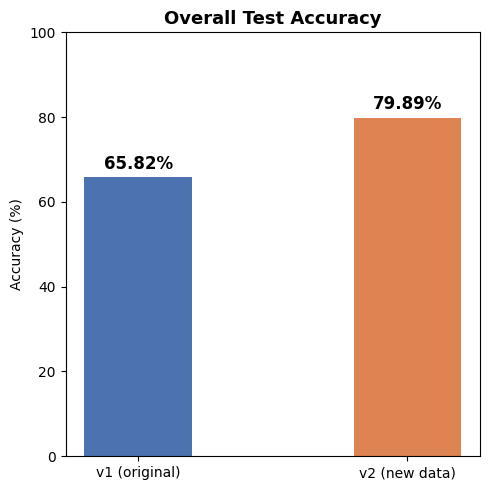

Saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison/accuracy_comparison.png

  GROUP 51 — COMPARISON SUMMARY
  v1 (original) accuracy : 65.82%
  v2 (new data) accuracy : 79.89%
    accuracy             : +14.08%  

  Outputs saved to: /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison


In [21]:
names  = list(results.keys())
accs   = [results[n]['acc'] * 100 for n in names]
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(names, accs, color=colors, width=0.4)
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Test Accuracy', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
acc_path = OUTPUT_DIR / 'accuracy_comparison.png'
plt.savefig(acc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {acc_path}')

# ── Delta summary ─────────────────────────────────────────────────────────
if len(results) == 2:
    v1_acc, v2_acc = accs
    delta = v2_acc - v1_acc
    sign  = '+' if delta >= 0 else ''
    print()
    print('=' * 45)
    print('  GROUP 51 — COMPARISON SUMMARY')
    print('=' * 45)
    print(f'  v1 (original) accuracy : {v1_acc:.2f}%')
    print(f'  v2 (new data) accuracy : {v2_acc:.2f}%')
    print(f'    accuracy             : {sign}{delta:.2f}%  ')
    print('=' * 45)
    print(f'\n  Outputs saved to: {OUTPUT_DIR}')